## Learning Objectives

In this module, you will learn how to use geopandas for **aggregating** geometries (e.g., smaller statistical units into larger ones), **simplifying** geometries (e.g., to be shown at smaller map scales), and **classifying** numerical data into categories for map display. 

At the end of this module, you should be able to:
- combine geometries based on a common attribute (*dissolving* them),
- simplify geometries according to a maximum-error threshold
- create categories for numerical data based on classifiers such as *natural breaks*, *equal interval*, or *quantiles*

In [1]:
# Turn off unwanted warnings
import warnings
warnings.filterwarnings("ignore")

## Aggregating data

Data aggregation refers to a process where we combine data into groups. When doing spatial data aggregation, we merge the geometries together into coarser
units (based on some attribute), and can also calculate summary statistics for these combined geometries from the original, more detailed values. For example,
suppose that we are interested in studying continents, but we only have country-level data. If we aggregate the data by continent, we would convert the country-level data into a continent-level dataset.

In this section, we will aggregate the national parks in Washington DC by the **park label name**, i.e. the polygon features that have the same park name will be merged together.

Let’s start with loading `National_Parks.zip`:

In [2]:
import geopandas as gpd

parks = gpd.read_file('data/National_Parks.zip')

# Extract the columns we need
parks = parks[['LABEL','NAME','ADDRESS','OBJECTID','geometry']]

# Calculte the geometry length and area
parks['SHAPEAREA'] = parks.geometry.area
parks['SHAPELEN']  = parks.geometry.length

# Remove the rows with missing park label names
parks = parks[parks.LABEL.notna()]

print('Number of rows:', len(parks))
print('Number of unique park labels:', parks.LABEL.nunique())
#print('List of columns in the data: ', parks.columns)

parks.sort_values(by='LABEL').head(20)

Number of rows: 208
Number of unique park labels: 91


,LABEL,NAME,ADDRESS,OBJECTID,geometry,SHAPEAREA,SHAPELEN
335,Anacostia Park,"Anacostia Park, Section F","Anacostia River, Between Benning & Railroad Br...",337,"MULTIPOLYGON (((-8569054.348 4706339.609, -856...",2.858516e+03,303.209023
179,Anacostia Park,"Anacostia Park, Section G",Anacostia River (both Banks) Between DC Line &...,181,"POLYGON ((-8565748.987 4709142.876, -8565745.5...",4.827058e+03,373.416431
180,Anacostia Park,"Anacostia Park, Section G",Anacostia River (both Banks) Between DC Line &...,182,"POLYGON ((-8565644.659 4709126.564, -8565647.6...",5.566828e+02,90.181128
182,Anacostia Park,"Anacostia Park, Section G",Anacostia River (both Banks) Between DC Line &...,184,"POLYGON ((-8566048.381 4709081.931, -8566050.2...",1.907296e+03,255.712231
198,Anacostia Park,"Anacostia Park, Section G",Anacostia River (both Banks) Between DC Line &...,200,"MULTIPOLYGON (((-8567144.079 4708668.221, -856...",1.104910e+06,10353.225234
217,Anacostia Park,"Anacostia Park, Section G",Anacostia River (both Banks) Between DC Line &...,219,"MULTIPOLYGON (((-8567381.023 4708166.959, -856...",1.585072e+04,675.580780
228,Anacostia Park,"Anacostia Park, Section G",Anacostia River (both Banks) Between DC Line &...,230,"POLYGON ((-8567465.288 4708017.035, -8567468.4...",7.418146e+03,383.627540
250,Anacostia Park,"Anacostia Park, Section G",Anacostia River (both Banks) Between DC Line &...,252,"POLYGON ((-8567629.523 4707660.838, -8567631.9...",2.078441e+04,763.659018
162,Anacostia Park,"Anacostia Park, Section G",Anacostia River (both Banks) Between DC Line &...,164,"MULTIPOLYGON (((-8565885.593 4708848.010, -856...",2.268636e+06,16756.093468
299,Anacostia Park,"Anacostia Park, Section F","Anacostia River, Between Benning & Railroad Br...",301,"POLYGON ((-8567791.355 4706958.570, -8567795.2...",1.317772e+06,10679.494701


In [3]:
parks.explore()

As you can see, there are more rows than unique park labels, because some parks consist of multiple polygons. For example, Anacostia Park consists of multiple sections. 

Our objective is to aggregate the polygons associated with the same park label. For aggregation, we will use `.dissolve()` method which takes the `LABEL` column as input for conducting aggregation:

In [4]:
# Conduct the aggregation
dissolved = parks.dissolve(by="LABEL")

#Verify the aggregation output
print('Number of rows:', len(dissolved))
print('Number of unique park labels:', dissolved.index.nunique())
dissolved.head(10)

Number of rows: 91
Number of unique park labels: 91


,geometry,NAME,ADDRESS,OBJECTID,SHAPEAREA,SHAPELEN
LABEL,,,,,,
Anacostia Park,"MULTIPOLYGON (((-8569115.638 4703695.515, -856...","Anacostia Park, Section G",Anacostia River (both Banks) Between DC Line &...,152,330637.040317,6237.191136
Archbold Parkway,"MULTIPOLYGON (((-8580361.311 4708958.680, -858...",Archbold Parkway,"West Side Glover Archbold Parkway, Between U s...",156,116813.392946,1886.598247
Bald Eagle Hill,"POLYGON ((-8572278.131 4695710.917, -8572298.0...",Bald Eagle Hill,"Giesboro Rd. & Southern Ave., SW",455,146232.714917,1982.396366
Baltimore Washington Parkway,"MULTIPOLYGON (((-8564895.506 4709763.693, -856...",Baltimore Washington Parkway,DC Line To Md Rt. 176,139,79831.290909,2047.949562
Barnard Hill,"POLYGON ((-8568303.254 4712776.636, -8568313.0...",Barnard Hill,"24th St., Between Randolph st. & Eastern Ave., NW",84,153508.116807,1860.926609
Battery Kemble Park,"POLYGON ((-8582189.542 4711751.509, -8582250.3...",Battery Kemble Park,"Chain Bridge Rd., South Of Nebraska Av. & Litt...",115,19983.148550,592.494820
Battery Ricketts,"POLYGON ((-8568859.363 4701134.722, -8568872.2...",Battery Ricketts,"Fort Pl. Between Pearson & Bruce Pl., SE",443,67035.181128,1107.166960
Battleground National Cemetery,"POLYGON ((-8574531.327 4717467.839, -8574534.3...",Battleground National Cemetery,"Georgia Ave., Between Whittier Pl. & Van Buren...",7,6651.391625,325.366259
Beach Parkway,"MULTIPOLYGON (((-8576502.480 4720515.499, -857...",Beach Parkway,"DC Line, Between East & West Beach Drive, NW",1,119754.492397,3563.113816


There are a few important things about the aggregation output:
- The number of rows is reduced from 208 to 91, because the polygon features with the same label are merged. 
- The difference between `.dissolve(by="column")` and `.groupby("column")`: groupby() does NOT automatically merge geometries, while dissolve() performs attribute aggregation and geometric merging in a single step.
- The `LABEL` column we used for conducting aggregation does not exist in the columns list anymore. Instead, `LABEL` becomes the new index of the dissolved GeoDataFrame:

In [5]:
dissolved.index

Index(['Anacostia Park', 'Archbold Parkway', 'Bald Eagle Hill',
       'Baltimore Washington Parkway', 'Barnard Hill', 'Battery Kemble Park',
       'Battery Ricketts', 'Battleground National Cemetery', 'Beach Parkway',
       'Benjamin Banneker Park', 'Brentwood Park', 'Bryce Park',
       'Buzzard Point', 'Chesapeake & Ohio Canal National Historical Park',
       'Chevy Chase Circle', 'Clara Barton Parkway', 'Columbus Circle',
       'Dalecarlia Parkway', 'Dumbarton Oaks Park', 'Dupont Circle',
       'East Potomac Park', 'Edward J. Kelly Park', 'FDR Memorial Stone',
       'Farragut Square', 'Folger Park', 'Fort Bayard Park',
       'Fort Bunker Hill', 'Fort Chaplin Park', 'Fort Circle Park',
       'Fort Davis', 'Fort Dupont Park', 'Fort Mahan Park', 'Fort Slocum Park',
       'Fort Stanton Park', 'Fort Stevens Park', 'Fort Totten Park',
       'Francis G. Newlands Park', 'Franklin Square',
       'Frederick Douglass Home', 'Glover Parkway & Children's Playground',
       'Grant Ci

Now we can select the geometry for any specific park:

In [6]:
dissolved.loc['Anacostia Park']

geometry     MULTIPOLYGON (((-8569115.638005368 4703695.515...
NAME                                 Anacostia Park, Section G
ADDRESS      Anacostia River (both Banks) Between DC Line &...
OBJECTID                                                   152
SHAPEAREA                                        330637.040317
SHAPELEN                                           6237.191136
Name: Anacostia Park, dtype: object

In [7]:
# See the data type
type(dissolved.loc['Anacostia Park'])

pandas.core.series.Series

As we can see, we have now a Pandas `Series` object containing basically one row from our original aggregated GeoDataFrame.

Let’s also visualize this selected row. But first, we need to convert the selected row back to a GeoDataFrame:

In [8]:
# Create a GeoDataFrame
selection = gpd.GeoDataFrame([dissolved.loc['Anacostia Park']], crs=dissolved.crs)

Plot the selection on top of the entire map:

<Axes: >

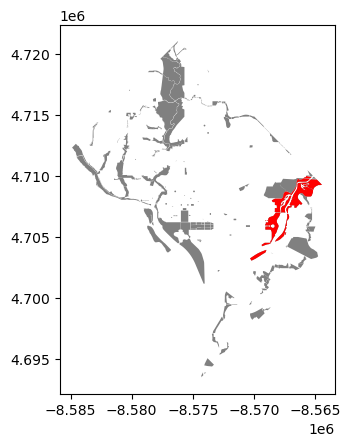

In [9]:
# Plot all the parks, and then the selected park.
ax = dissolved.plot(facecolor="gray")
selection.plot(ax=ax, facecolor="red")

> **How Are Other Columns Aggregated During `dissolve`?**  
> 
> When using the `dissolve` method in GeoPandas (e.g., `dissolved = parks.dissolve(by="LABEL")`), here's how other columns are aggregated:
> 
> ### Default Behavior:
> - **Default Aggregation Function:** `aggfunc='first'`
>   - Keeps the **first value** from each group for columns that are not involved in the aggregation.
>   - For multiple rows grouped together, only the first row's values are retained for other columns.
> 
> ### Custom Aggregation:
> You can control how other columns are aggregated using the `aggfunc` parameter:
> ```python
> dissolved = parks.dissolve(by="LABEL", aggfunc="sum")
> ```
> Supported aggregation functions include:
> - `"sum"`: Sum of the values in the group.
> - `"mean"`: Average of the values in the group.
> - `"min"`: Minimum value in the group.
> - `"max"`: Maximum value in the group.
> - `"first"`: First value in the group (default).
> - `"last"`: Last value in the group.
> - Custom aggregation using a `lambda` function.
> 
> ### Using Multiple Aggregations:
> To apply different aggregations to different columns, you can do further aggregation manually:
> ```python
> dissolved = parks.dissolve(
>    by="LABEL", 
>    aggfunc={
>     "column1": "sum",
>     "column2": "mean",
>     "column3": "max"
> })
> ```
> 
> ### Geometry Aggregation:
> - The geometries in the grouped rows are **merged (unioned)** into a single geometry for each group.

Let's change the aggregation rules for the `SHAPELEN` and `SHAPEAREA` columns by summing up the length and area of all features for the same park label:

In [10]:
dissolved = parks.dissolve(
    by='LABEL',
    aggfunc={
    'ADDRESS':'first',
    'SHAPELEN':'sum',
    'SHAPEAREA':'sum',
    })
dissolved

,geometry,ADDRESS,SHAPELEN,SHAPEAREA
LABEL,,,,
Anacostia Park,"MULTIPOLYGON (((-8569115.638 4703695.515, -856...",Anacostia River (both Banks) Between DC Line &...,59913.265032,5.889218e+06
Archbold Parkway,"MULTIPOLYGON (((-8580361.311 4708958.680, -858...","West Side Glover Archbold Parkway, Between U s...",6279.948449,4.476684e+05
Bald Eagle Hill,"POLYGON ((-8572278.131 4695710.917, -8572298.0...","Giesboro Rd. & Southern Ave., SW",1982.396366,1.462327e+05
Baltimore Washington Parkway,"MULTIPOLYGON (((-8564895.506 4709763.693, -856...",DC Line To Md Rt. 176,2930.598806,1.115261e+05
Barnard Hill,"POLYGON ((-8568303.254 4712776.636, -8568313.0...","24th St., Between Randolph st. & Eastern Ave., NW",1860.926609,1.535081e+05
...,...,...,...,...
Washington Monument & Grounds,"POLYGON ((-8575357.316 4706211.715, -8575357.3...","14th To 17th Sts., E St. To Constitution Ave., NW",4208.443300,6.984447e+05
Westmoreland Circle,"POLYGON ((-8582885.058 4714340.820, -8582824.1...","Massachusetts & Western Aves., NW",270.510994,5.082453e+03
White House Grounds,"POLYGON ((-8575366.685 4706243.997, -8575970.4...","Pennsylvania Ave., Between 15th & 17th Streets NW",3061.022297,5.595503e+05


## Simplifying geometries


Sometimes it might be useful to be able to simplify geometries. This could be something to consider when you have very detailed spatial features. If you make a map that covers the whole world, it is unnecessary to have really detailed geometries because it is simply impossible to see those small details from your map. Furthermore, it takes a long time to render a large quantity of features into a map. Here, we will see how it is possible to simplify geometric features in Python.

As an example we will use data representing the Amazon river in South America, and simplify its geometries.

Let's first read the data and see how the river looks like:

In [11]:
import geopandas as gpd

amazon = gpd.read_file("data/amazon_river.gpkg")
amazon.head()

,bbox_east,bbox_north,bbox_south,bbox_west,place_name,geometry
0,-49.10927,0.70653,-4.44219,-73.450126,"Rio Amazonas, Microrregião de Manaus, Mesorreg...","MULTILINESTRING ((1612358.589 9508606.173, 161..."


In [12]:
amazon.crs

<Projected CRS: PROJCS["Mercator_2SP",GEOGCS["GCS_GRS 1980(IUGG, 1 ...>
Name: Mercator_2SP
Axis Info [cartesian]:
- [east]: Easting (metre)
- [north]: Northing (metre)
Area of Use:
- undefined
Coordinate Operation:
- name: unnamed
- method: Mercator (variant B)
Datum: D_unknown
- Ellipsoid: GRS80
- Prime Meridian: Unknown

<Axes: >

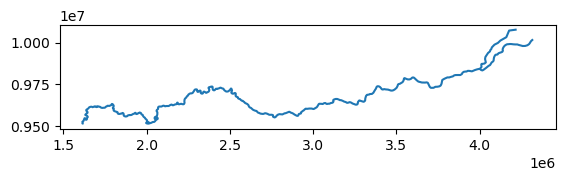

In [13]:
amazon.plot()

The LineString is quite detailed. Let's see how we can generalize them a bit. As we can see from the coordinate reference system,
the data is projected in a system using Mercator projection and metres as a unit. 

Generalization can be done by using a Shapely function called `.simplify()`. The `tolerance` parameter can be used to adjusts how much geometries should be generalized. **The tolerance value is tied to the coordinate system of the geometries**. Here we pass a value of 20,000 **meters** (20 kilometers).

<Axes: >

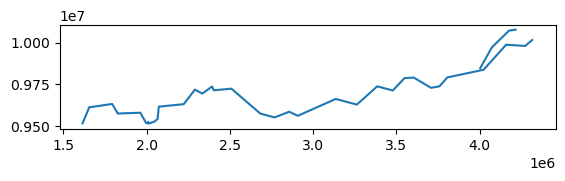

In [14]:
# Generalize geometry
amazon['simplegeom'] = amazon.simplify(tolerance=20000)

# Set geometry to be our new simplified geometry
amazon = amazon.set_geometry('simplegeom')

# Plot
amazon.plot()

As a result, we have simplified our LineString quite significantly.

## Reclassifying data

Reclassifying data based on specific criteria is a common task in GIS.

In this section we will use a USCounties dataset to see how we can reclassify vector data using the PySAL [mapclassify library](https://pysal.org/mapclassify/). The file (in Shapefile) contains information of the population demographics in each county.

In [15]:
uscounty = gpd.read_file('data/USCounties.zip')

# Calculate the ratio of Male to Female populations
uscounty['M2F'] = uscounty['MALES']/uscounty['FEMALES']

uscounty.head(5)

,ObjectID,NAME,STATE_NAME,FIPS,POP2000,POP00_SQMI,MALES,FEMALES,MED_AGE,HOUSEHOLDS,...,CalcFarmAc,FarmAcres,CropAcres,CrpValAv,CrpValTot,FrmrAge,Cows,AvgAge,geometry,M2F
0,0,Siskiyou,California,06093,44301,7.0,21752,22549,43.0,18556,...,628914.0,628914.0,182185.0,719.83,1.311422e+08,56.4,66665,63.743756,"POLYGON ((-2263443.001 2373524.342, -2263269.8...",0.964655
1,1,Big Horn,Montana,30003,12671,2.5,6249,6422,29.8,3924,...,2770310.0,2770310.0,407958.0,104.68,4.270504e+07,54.2,86434,20.910138,"POLYGON ((-961891.533 2507738.015, -961894.810...",0.973061
2,8,Del Norte,California,06015,27507,27.1,15186,12321,36.4,9170,...,13332.0,13332.0,8039.0,3414.01,2.744523e+07,55.8,9858,42.229026,"POLYGON ((-2292563.856 2394672.986, -2292561.7...",1.232530
3,9,Linn,Oregon,41043,103069,44.6,50880,52189,37.4,39541,...,393764.0,393764.0,304964.0,481.70,1.469012e+08,55.3,32958,46.734171,"POLYGON ((-2028816.907 2640191.920, -2029870.1...",0.974918
4,10,Benton,Oregon,41003,78153,115.1,38905,39248,31.1,30145,...,130680.0,130680.0,91750.0,940.55,8.629546e+07,54.1,6887,29.733635,"POLYGON ((-2179108.518 2686663.840, -2179075.9...",0.991261


In [16]:
# Print the list of columns
uscounty.columns

Index(['ObjectID', 'NAME', 'STATE_NAME', 'FIPS', 'POP2000', 'POP00_SQMI',
       'MALES', 'FEMALES', 'MED_AGE', 'HOUSEHOLDS', 'AVE_HH_SZ', 'HSE_UNITS',
       'VACANT', 'OWNER_OCC', 'RENTER_OCC', 'NO_FARMS97', 'AVG_SIZE97',
       'ROBB01', 'ASSA01', 'BURG01', 'LARC01', 'ARSO01', 'AgeUnder21',
       'Age22to64', 'Age65plus', 'CountyAcre', 'CalcFarmAc', 'FarmAcres',
       'CropAcres', 'CrpValAv', 'CrpValTot', 'FrmrAge', 'Cows', 'AvgAge',
       'geometry', 'M2F'],
      dtype='object')

## Common classifiers

[PySAL](https://pysal.org/) is an extensive Python library for spatial analysis. It includes many common data classifiers. Below are the map classifiers in [pysal's mapclassify module](https://github.com/pysal/mapclassify):
- Box Plot
- Equal Interval
- Fisher Jenks
- Fisher Jenks Sampled
- HeadTail Breaks
- Jenks Caspall
- Jenks Caspall Forced
- Jenks Caspall Sampled
- Max P Classifier
- Maximum Breaks
- Natural Breaks
- Quantiles
- Percentiles
- Std Mean
- User Defined

Let's plot the `M2F` column:
- `cmap` defines the color map. Read more about [choosing colormaps in matplotlib](https://matplotlib.org/3.1.0/tutorials/colors/colormaps.html)
- `scheme` scales the colors according to a classification scheme (requires `mapclassify` module to be installed):

<Axes: >

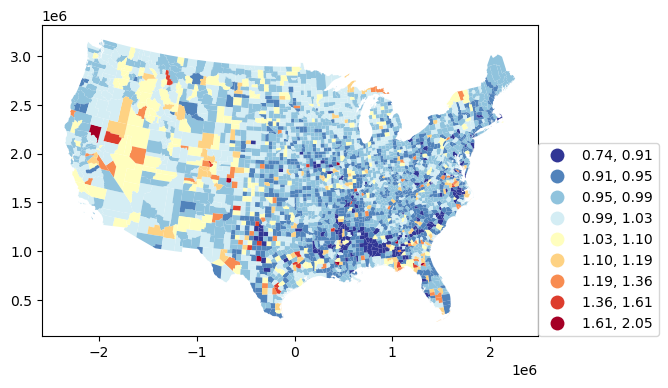

In [17]:
# Use 9 classes and classify the values using "Natural Breaks" classification
uscounty.plot(column='M2F',scheme="Natural_Breaks",k=9,cmap="RdYlBu_r",linewidth=0,legend=True,legend_kwds={'loc':(1,0)})

### Applying classifiers to data

As mentioned, the `scheme` option defines the classification scheme using `pysal/mapclassify`. Let's have a closer look at how these classifiers work.

### Natural Breaks

In [18]:
import mapclassify
mapclassify.NaturalBreaks(y=uscounty['M2F'], k=9)

NaturalBreaks

  Interval     Count
--------------------
[0.74, 0.91] |   168
(0.91, 0.95] |   767
(0.95, 0.99] |  1066
(0.99, 1.03] |   655
(1.03, 1.10] |   229
(1.10, 1.19] |   105
(1.19, 1.36] |    53
(1.36, 1.61] |    19
(1.61, 2.05] |     7

### Quantiles (default is 5 classes):

In [19]:
mapclassify.Quantiles(y=uscounty['M2F'])

Quantiles

  Interval     Count
--------------------
[0.74, 0.94] |   614
(0.94, 0.96] |   614
(0.96, 0.98] |   613
(0.98, 1.01] |   614
(1.01, 2.05] |   614

### Extract threshold values

It's possible to extract the threshold values into an array:

In [20]:
classifier = mapclassify.NaturalBreaks(y=uscounty['M2F'], k=9)
classifier.bins

array([0.90722693, 0.9488594 , 0.98447607, 1.02912621, 1.09648639,
       1.19260344, 1.36106701, 1.60948081, 2.05368013])

Let's apply one of the `Pysal` classifiers into our data and classify the population into 9 classes.
The classifier needs to be initialized first with `make()` function that takes the number of desired classes as input parameter.

In [21]:
# Create a Natural Breaks classifier
classifier = mapclassify.NaturalBreaks.make(k=9)

Now we can apply that classifier into our data by using `apply` -function

In [22]:
# Classify the data
classifications = uscounty[['M2F']].apply(classifier)
classifications.head()

,M2F
0,2
1,2
2,6
3,2
4,3


In [23]:
type(classifications)

pandas.core.frame.DataFrame

Now we have a DataFrame where our input column was classified into 9 different classes (numbers 1-9) based on [Natural Breaks
classification](https://en.wikipedia.org/wiki/Jenks_natural_breaks_optimization).

We can also add the classification values directly into a new column in our dataframe:

In [24]:
# Rename the column so that we know that it was classified with natural breaks
uscounty["M2F_Class"] = uscounty[["M2F"]].apply(classifier)

# Check the original values and classification
uscounty[["M2F", "M2F_Class"]].head()

,M2F,M2F_Class
0,0.964655,2
1,0.973061,2
2,1.232530,6
3,0.974918,2
4,0.991261,3


Great, now we have those values in the `uscounty` GeoDataFrame. Let's visualize the results and see how they look.

<Axes: >

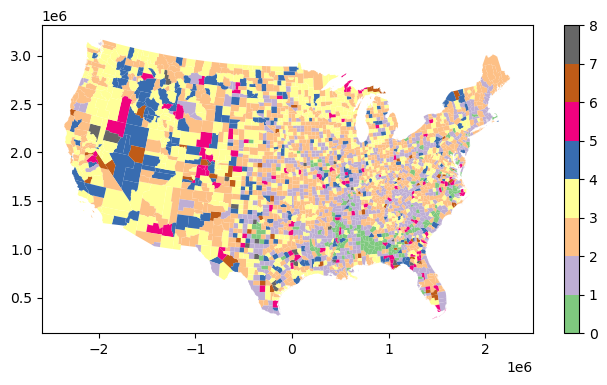

In [25]:
uscounty.plot(column="M2F_Class",cmap="Accent",linewidth=0,legend=True,figsize=(8,4))

Now we have a map where we have used one of the common classifiers to classify our data into 9 classes.

## Plotting a histogram

A histogram is a graphic representation of the distribution of the data. When classifying the data, it's always good to consider how the data is distributed, and how the classification scheme divides values into different ranges. 

- Plot the histogram using [pandas.DataFrame.plot.hist](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.plot.hist.html)
- Number of histogram bins (groups of data) can be controlled using the parameter `bins`:

<Axes: ylabel='Frequency'>

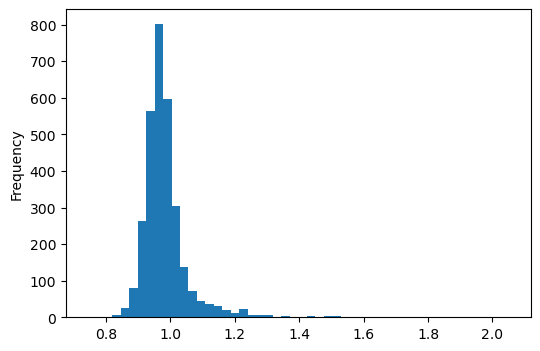

In [26]:
uscounty["M2F"].plot.hist(bins=50,figsize=(6,4))

Let's also add threshold values on top of the histogram as vertical lines.

- Natural Breaks:

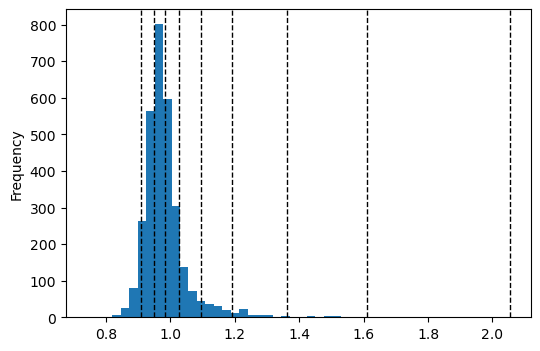

In [27]:
import matplotlib.pyplot as plt

# Define classifier
classifier = mapclassify.NaturalBreaks(y=uscounty["M2F"], k=9)

# Plot histogram
uscounty["M2F"].plot.hist(bins=50,figsize=(6,4))

# Add vertical lines for class breaks
for break_point in classifier.bins:
    plt.axvline(break_point, color="k", linestyle="dashed", linewidth=1)

- Quantiles:

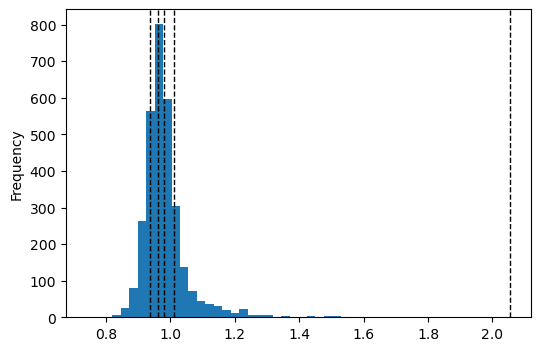

In [28]:
# Define classifier
classifier = mapclassify.Quantiles(y=uscounty["M2F"])

# Plot histogram
uscounty["M2F"].plot.hist(bins=50,figsize=(6,4))

for break_point in classifier.bins:
    plt.axvline(break_point, color="k", linestyle="dashed", linewidth=1)

## Applying a custom classifier

### Multicriteria data classification

Let's classify the geometries into two classes based on a given `threshold` parameter. We will use a [lambda function](https://autogis-site.readthedocs.io/en/latest/lessons/lesson-1/exercise-1.html#apply-ing-an-anonymous-lambda-function) to classify each row in the GeoDataFrame. The classification returns 1 if the condition is True, and 0 if the condition if False. This is called [binary classification](https://en.wikipedia.org/wiki/Binary_classification).

Let's perform a binary classification of `M2F` based on the following criteria:

1. M2F greater than 1.2
2. *or* M2F less than 0.8

In [29]:
uscounty["M2F_imbalanced"] = uscounty.apply(lambda row: int(row["M2F"]>1.2 or row["M2F"]<0.8), axis=1)

In [30]:
uscounty.head()

,ObjectID,NAME,STATE_NAME,FIPS,POP2000,POP00_SQMI,MALES,FEMALES,MED_AGE,HOUSEHOLDS,...,CropAcres,CrpValAv,CrpValTot,FrmrAge,Cows,AvgAge,geometry,M2F,M2F_Class,M2F_imbalanced
0,0,Siskiyou,California,06093,44301,7.0,21752,22549,43.0,18556,...,182185.0,719.83,1.311422e+08,56.4,66665,63.743756,"POLYGON ((-2263443.001 2373524.342, -2263269.8...",0.964655,2,0
1,1,Big Horn,Montana,30003,12671,2.5,6249,6422,29.8,3924,...,407958.0,104.68,4.270504e+07,54.2,86434,20.910138,"POLYGON ((-961891.533 2507738.015, -961894.810...",0.973061,2,0
2,8,Del Norte,California,06015,27507,27.1,15186,12321,36.4,9170,...,8039.0,3414.01,2.744523e+07,55.8,9858,42.229026,"POLYGON ((-2292563.856 2394672.986, -2292561.7...",1.232530,6,1
3,9,Linn,Oregon,41043,103069,44.6,50880,52189,37.4,39541,...,304964.0,481.70,1.469012e+08,55.3,32958,46.734171,"POLYGON ((-2028816.907 2640191.920, -2029870.1...",0.974918,2,0
4,10,Benton,Oregon,41003,78153,115.1,38905,39248,31.1,30145,...,91750.0,940.55,8.629546e+07,54.1,6887,29.733635,"POLYGON ((-2179108.518 2686663.840, -2179075.9...",0.991261,3,0


How many counties have imbalanced male to female ratios? Let's find out by using a Pandas function `.value_counts()` to return the count of different values in the `M2F` column.

In [31]:
# Get value counts
uscounty["M2F_imbalanced"].value_counts()

M2F_imbalanced
0    2989
1      80
Name: count, dtype: int64

Ok there are 80 counties with imbalanced male to female ratios. Let's see where they are located:

<Axes: >

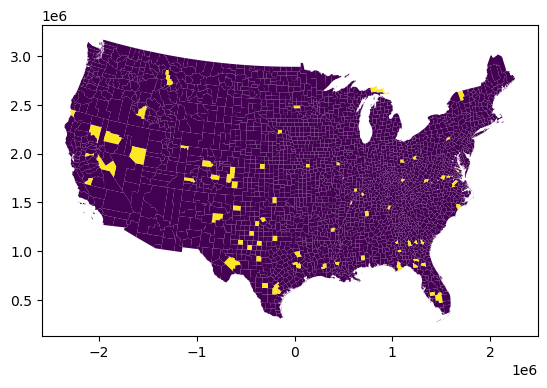

In [32]:
uscounty.plot(column="M2F_imbalanced", linewidth=0)